# 🌟 Rating Prediction — Features Otimizadas

Objetivo: Prever o rating (1–5) de avaliações em português usando features linguísticas.

**Estratégia:** 28 features linguísticas (léxicos PT-BR + SentiLex + tom ambíguo) — sem TF-IDF.


## 1. Imports e Carregamento dos Dados

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, cohen_kappa_score

import nltk
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment import SentimentIntensityAnalyzer

SEED = 42
print('✅ Imports concluídos!')

✅ Imports concluídos!


In [65]:
# ── Ajuste os caminhos conforme necessário ──
train = pd.read_csv('data/train.csv')
test  = pd.read_csv('data/test.csv')

train['text']  = train['text'].fillna('')
train['title'] = train['title'].fillna('')
test['text']   = test['text'].fillna('')
test['title']  = test['title'].fillna('')

print(f'Train: {train.shape}  |  Test: {test.shape}')
print(f'\nColunas: {train.columns.tolist()}')
train.head()

Train: (41005, 5)  |  Test: (10252, 4)

Colunas: ['id', 'ASIN', 'text', 'title', 'rating']


,id,ASIN,text,title,rating
0,17578,B07FSVFWDS,"Por incrível que pareça, para uma bebida desti...",Vodka diferenciada,5
1,18658,B08ZHC4VNJ,"O readset pode até ser bom, mais tem outros fo...",Absurdo,1
2,28477,8545202539,"Foi difícil terminar esse livro , demorou mese...",Decepção,2
3,43638,B0081Z77YI,"A bola é boa divertida, mas não é nem um pouco...","Não é indicada para cães grandes, nem mesmo a ...",2
4,26130,857860184X,Comprei errado! Não tenho leitor de e-books. Q...,Enganei,1


## 2. Distribuição de Ratings

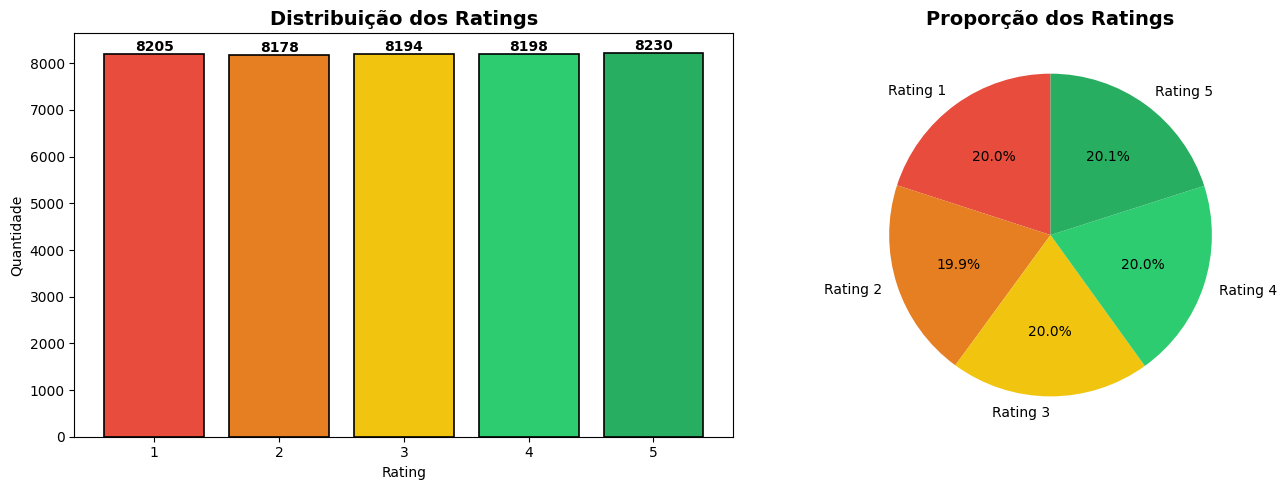


Distribuição:
rating
1    8205
2    8178
3    8194
4    8198
5    8230
Name: count, dtype: int64

Dataset balanceado: 0.2% de variação (ideal = 0%)


In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contagem
counts = train['rating'].value_counts().sort_index()
colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']

bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=1.2)
axes[0].set_title('Distribuição dos Ratings', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Quantidade')
for bar, val in zip(bars, counts.values):
    axes[0].annotate(f'{val}', xy=(bar.get_x() + bar.get_width()/2, val),
                     ha='center', va='bottom', fontweight='bold')

# Proporção
axes[1].pie(counts.values, labels=[f'Rating {i}' for i in counts.index],
            colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporção dos Ratings', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nDistribuição:')
print(counts)
print(f'\nDataset balanceado: {counts.std()/counts.mean()*100:.1f}% de variação (ideal = 0%)')

## 3. Instâncias de Cada Rating

In [67]:
print('=' * 80)
print('EXEMPLOS DE AVALIAÇÕES POR RATING')
print('=' * 80)

for rating in sorted(train['rating'].unique()):
    sample = train[train['rating'] == rating].iloc[0]
    print(f'\n⭐ RATING {rating}')
    print(f'  Título : {sample["title"]}')
    print(f'  Texto  : {sample["text"][:250]}...' if len(sample['text']) > 250 else f'  Texto: {sample["text"]}')
    print('-' * 80)

EXEMPLOS DE AVALIAÇÕES POR RATING

⭐ RATING 1
  Título : Absurdo
  Texto: O readset pode até ser bom, mais tem outros fones no mesmo nível que custam mais baratos, na faixa de R$ 600 a R$ 700 reais, uma pena que veio para o Brasil com esse abuso de preço. Um absurdo isso!
--------------------------------------------------------------------------------

⭐ RATING 2
  Título : Decepção
  Texto  : Foi difícil terminar esse livro , demorou meses ,  cansativo e nada prático,  78% desse livro comentários ou citação de outros livros e mestres. ( nada prático) o restante do próprio autor nada realmente fosse útil  . Eu achei casos citado pelo autor...
--------------------------------------------------------------------------------

⭐ RATING 3
  Título : Ruim
  Texto: Bermuda ruim d++++ eu não recomendo
--------------------------------------------------------------------------------

⭐ RATING 4
  Título : Tamanho pequeno
  Texto: GG diz servir até tamanho 50, porém uso 46 e ficou um tanto aperta

## 4. Léxicos e recursos linguísticos

Nesta secção ficam **todos** os conjuntos e ficheiros usados pelas features (evita duplicar listas noutras células).

- **Primeira célula de código:** polaridade manual (PT-BR), negações, **SentiLex** e instância VADER (`sia`).
- **Célula seguinte:** conjuntos para **tom ambíguo** (contraste, hedging, comparação, preço e padrões de frase).



In [68]:
# ─────────────────────────────────────────────
#  Palavras positivas (PT-BR)
# ─────────────────────────────────────────────
POSITIVE_WORDS = set([
    # qualidade
    'bom','boa','bons','boas','ótimo','ótima','ótimos','ótimas',
    'excelente','excelentes','incrível','incríveis','maravilhoso','maravilhosa',
    'maravilhosos','maravilhosas','fantástico','fantástica','fantásticos',
    'fantásticas','perfeito','perfeita','perfeitos','perfeitas','espetacular',
    'espetaculares','sensacional','sensacionais','top','premium','qualidade',
    # emoção
    'gostei','gostar','adoro','adorei','adoramos','amei','amar','amo',
    'satisfeito','satisfeita','satisfeitos','feliz','felizes','alegre',
    'contente','encantado','encantada','impressionado','impressionada',
    'surpreendido','surpreendida','surpreso','surpresa',
    # recomendação
    'recomendo','recomendado','recomendada','recomendável','indico','vale',
    'compensa','ótima compra','valeu','valendo',
    # utilidade
    'funciona','funcionou','funcionando','funcional','prático','prática',
    'eficiente','eficientes','eficaz','eficazes','útil','úteis','rápido',
    'rápida','rápidos','fácil','fáceis','simples','resistente',
    # aparência
    'bonito','bonita','bonitos','bonitas','lindo','linda','lindos','lindas',
    'elegante','elegantes','moderno','moderna','design',
    # outros
    'agradável','agradáveis','confortável','confortáveis','original',
    'genuíno','autêntico','durável','resistente','robusto','robusto',
    'melhor','melhores','brilhante','amável','confiável','bem','super',
    'muito bom','muito boa','muito bem','bastante'
])

# ─────────────────────────────────────────────
#  Palavras negativas (PT-BR)
# ─────────────────────────────────────────────
NEGATIVE_WORDS = set([
    # qualidade
    'ruim','ruins','péssimo','péssima','péssimos','péssimas',
    'horrível','horríveis','terrível','terríveis','horroroso','horrorosa',
    'deplorável','lamentável','miserável','ridículo','ridícula','absurdo','absurda',
    'lixo','lixeira','inútil','inúteis','imprestável','imprestáveis','fraco','fraca',
    # emoção
    'odiei','odiar','odeio','detestei','detestar','detesto','decepcionado',
    'decepcionada','decepcionante','decepcionou','decepciona','frustrado',
    'frustrada','frustrante','insatisfeito','insatisfeita','triste','raiva',
    'irritante','irritado','irritada','aborrecido','chateado','chateada',
    # problema
    'problema','problemas','defeito','defeitos','falha','falhas','erro','erros',
    'bug','bugs','quebrado','quebrada','danificado','danificada','estragado',
    'estragada','travou','travando','lento','lenta','lentos','lentas',
    # desonestidade
    'enganoso','enganosa','enganado','enganada','fraude','fraudulento','falso',
    'falsa','propaganda','mentira','mentiroso','desperdício','arrependido',
    # custo
    'caro','cara','caros','caras','abusivo','abusiva','injusto','injusta',
    # intensificadores negativos
    'pior','piores','jamais','nunca mais','horrendo','horrenda','insuportável',
    'insuportáveis','desagradável','desagradáveis','demorado','demorada',
    'demora','atraso','atrasado'
])

# ─────────────────────────────────────────────
#  Negações
# ─────────────────────────────────────────────
NEGATION_WORDS = {'não','nao','nunca','nem','jamais','nenhum','nenhuma','nada'}


CONTRAST_WORDS = {
    'mas', 'porém', 'porem', 'contudo', 'todavia', 'entretanto', 'senão', 'senao',
    'embora', 'enquanto', 'outrossim',
}

HEDGE_WORDS = {
    'meio', 'pouco', 'relativamente', 'razoável', 'razoavel', 'regular', 'nem',
    'quase', 'mediano', 'medíocre', 'mediocre', 'ok', 'talvez', 'duvidoso',
    'satisfatório', 'satisfatorio', 'aceitável', 'aceitavel', 'assim-assim',
}

COMPARATIVE_WORDS = {
    'melhor', 'pior', 'igual', 'similar', 'parecido', 'parecida', 'comparado',
    'comparada', 'comparar', 'versus', 'superior', 'inferior', 'equivalente',
}

PRICE_CONTEXT_WORDS = {
    'preço', 'preco', 'barato', 'caro', 'caros', 'caras', 'reais', 'real',
    'custo', 'econômico', 'economico', 'faixa', 'valor', 'promoção', 'promocao',
}

# Padrões multi-palavra (texto já em minúsculas)
CONTRAST_PHRASE_PATTERNS = [
    r'(?:só|so)\s+que',
    r'mesmo\s+assim',
    r'apesar\s+de',
    r'por\s+outro\s+lado',
    r'por\s+um\s+lado',
    r'ainda\s+assim',
    r'no\s+entanto',
    r'tanto\s+faz',
]

print(f'✅ Léxico positivo: {len(POSITIVE_WORDS)} palavras')
print(f'✅ Léxico negativo: {len(NEGATIVE_WORDS)} palavras')


✅ Léxico positivo: 116 palavras
✅ Léxico negativo: 109 palavras


In [69]:
# ─────────────────────────────────────────────
#  SentiLex (data/sentilex.txt) e instância VADER (`sia`)
# ─────────────────────────────────────────────
sia = SentimentIntensityAnalyzer()

SENTILEX = {}
try:
    with open('data/sentilex.txt', encoding='utf-8') as f:
        for line in f:
            parts = line.split(';')
            word = parts[0].split(',')[0].split('.')[0]
            polarity = 0
            for p in parts:
                if 'POL:N0=' in p:
                    try:
                        polarity = int(p.split('=')[1])
                    except:
                        pass
            if word not in SENTILEX or abs(polarity) > abs(SENTILEX[word]):
                SENTILEX[word] = polarity
    print(f'✅ SentiLex carregado: {len(SENTILEX)} entradas')
except FileNotFoundError:
    print('⚠️  SentiLex não encontrado — features de sentilex serão zero.')

✅ SentiLex carregado: 7010 entradas


## 5. Extração de Features

### Visão geral (28 features — mesma ordem que `FEATURE_NAMES`)

| # | Feature | Grupo | Ideia |
|---|---------|-------|-------|
| 1 | `word_count` | Estrutural | Volume do texto |
| 2 | `avg_word_length` | Lexical | Tamanho médio das palavras |
| 3 | `sentence_count` | Estrutural | Número de frases |
| 4 | `avg_words_per_sentence` | Estrutural | Palavras por frase |
| 5 | `exclamation_count` | Pontuação | Exclamações |
| 6 | `positive_word_count` | Sentimento | Léxico positivo PT-BR (sec. 4) |
| 7 | `negative_word_count` | Sentimento | Léxico negativo PT-BR (sec. 4) |
| 8 | `sentiment_score` | Sentimento | positivos − negativos |
| 9 | `sentiment_ratio` | Sentimento | positivos / (pos + neg) |
| 10 | `negation_count` | Sentimento | Negações explícitas |
| 11 | `negated_positive_count` | Sentimento | Padrão “não + positivo” |
| 12 | `sentilex_score` | SentiLex | Soma de polaridades |
| 13 | `sentilex_positive` | SentiLex | Tokens com polaridade > 0 |
| 14 | `sentilex_negative` | SentiLex | Tokens com polaridade < 0 |
| 15 | `capital_ratio` | Intensidade | Proporção de maiúsculas |
| 16 | `uppercase_word_count` | Intensidade | Palavras em CAPS |
| 17 | `elongated_word_count` | Intensidade | Letras repetidas (ênfase) |
| 18 | `digit_count` | Lexical | Dígitos |
| 19 | `lexical_diversity` | Lexical | Palavras únicas / total |
| 20 | `emotional_intensity` | Intensidade | Exclamações + CAPS |
| 21 | `nao_density` | Sentimento | Frequência de “não” |
| 22 | `contrast_word_count` | Tom ambíguo | Conjunções adversativas |
| 23 | `contrast_phrase_count` | Tom ambíguo | Frases multi-palavra |
| 24 | `hedge_word_count` | Tom ambíguo | Atenuadores |
| 25 | `comparative_word_count` | Tom ambíguo | Comparações |
| 26 | `price_context_count` | Tom ambíguo | Vocabulário de preço |
| 27 | `hedge_ratio` | Tom ambíguo | Hedging / nº palavras |
| 28 | `contrast_ratio` | Tom ambíguo | (contraste palavra + frase) / nº palavras |



### 5.1 Funções individuais (documentadas)

Léxicos e listas de palavras estão na **secção 4**; aqui ficam apenas `tokenize_words`, contagens e agregações usadas no vetor final.



In [70]:
import re

# ─── 1. Função Base: Tokenização ───
def tokenize_words(text: str) -> list:
    """Lista de tokens alfanuméricos em minúsculas; 'nao' → 'não' para bater no léxico."""
    if not isinstance(text, str) or not text.strip():
        return []
    t = text.lower()
    raw = re.findall(r'\w+', t, flags=re.UNICODE)
    out = []
    for w in raw:
        if w == 'nao':
            w = 'não'
        out.append(w)
    return out

# ─── 2. Contagem de palavras ───
def word_count(text: str) -> int:
    """Número de tokens (tokenização Unicode)."""
    return len(tokenize_words(text))

# ─── 3. Comprimento médio das palavras ───
def avg_word_length(text: str) -> float:
    """Média do número de caracteres por palavra."""
    words = tokenize_words(text)
    if not words:
        return 0.0
    return sum(len(w) for w in words) / len(words)

# ─── 4. Número de sentenças ───
def sentence_count(text: str) -> int:
    """Número de sentenças separadas por '.', '!' ou '?'."""
    if not isinstance(text, str):
        return 1
    return max(1, len(re.split(r'[.!?]+', text)) - 1)

# ─── 5. Média de palavras por sentença ───
def avg_words_per_sentence(text: str) -> float:
    """Densidade de palavras por sentença."""
    sents = sentence_count(text)
    return word_count(text) / sents if sents else 0.0

# ─── 6. Contagem de '!' ───
def exclamation_count(text: str) -> int:
    """Exclamações: alta freq. nos extremos (rating 1 e 5)."""
    return text.count('!') if isinstance(text, str) else 0

# ─── 7. Contagem de palavras positivas ───
def positive_word_count(text: str) -> int:
    """Número de palavras do léxico positivo PT-BR."""
    words = tokenize_words(text)
    return sum(w in POSITIVE_WORDS for w in words)

# ─── 8. Contagem de palavras negativas ───
def negative_word_count(text: str) -> int:
    """Número de palavras do léxico negativo PT-BR."""
    words = tokenize_words(text)
    return sum(w in NEGATIVE_WORDS for w in words)

# ─── 9. Score de sentimento ───
def sentiment_score(text: str) -> int:
    """pos - neg: sinal direto da polaridade."""
    return positive_word_count(text) - negative_word_count(text)

# ─── 10. Ratio de sentimento ───
def sentiment_ratio(text: str) -> float:
    """pos / (pos + neg): proporção normalizada."""
    pos = positive_word_count(text)
    neg = negative_word_count(text)
    return pos / (pos + neg) if (pos + neg) > 0 else 0.5

# ─── 11. Contagem de negações ───
def negation_count(text: str) -> int:
    """Freq. de 'não','nem','nunca',etc. Muito mais alto em ratings 1-2."""
    words = tokenize_words(text)
    return sum(w in NEGATION_WORDS for w in words)

# ─── 12. Positivos negados ───
def negated_positive_count(text: str) -> int:
    """'não funciona', 'não recomendo' — sinal forte de insatisfação."""
    words = tokenize_words(text)
    count = 0
    for i, w in enumerate(words[:-1]):
        if w in NEGATION_WORDS and words[i + 1] in POSITIVE_WORDS:
            count += 1
    return count

# ─── 13. SentiLex Score ───
def sentilex_score(text: str) -> int:
    """Soma das polaridades no léxico SentiLex PT."""
    words = tokenize_words(text)
    return sum(SENTILEX.get(w, 0) for w in words)

# ─── 14. SentiLex positivo ───
def sentilex_positive(text: str) -> int:
    """Contagem de palavras com polaridade positiva no SentiLex."""
    words = tokenize_words(text)
    return sum(1 for w in words if SENTILEX.get(w, 0) > 0)

# ─── 15. SentiLex negativo ───
def sentilex_negative(text: str) -> int:
    """Contagem de palavras com polaridade negativa no SentiLex."""
    words = tokenize_words(text)
    return sum(1 for w in words if SENTILEX.get(w, 0) < 0)

# ─── 16. Capital ratio ───
def capital_ratio(text: str) -> float:
    """Proporção de letras maiúsculas. CAPS = ênfase emocional."""
    if not isinstance(text, str):
        return 0.0
    letters = [c for c in text if c.isalpha()]
    return sum(c.isupper() for c in letters) / len(letters) if letters else 0.0

# ─── 17. Palavras totalmente em maiúsculo ───
def uppercase_word_count(text: str) -> int:
    """Contagem de palavras CAPS. Rating 1 tem 0.42 vs 0.09 no rating 5."""
    if not isinstance(text, str):
        return 0
    return sum(1 for w in text.split() if w.isupper() and len(w) > 1)

# ─── 18. Palavras alongadas ───
def elongated_word_count(text: str) -> int:
    """Ex: 'muiiiito', 'pésssimooo' — ênfase emocional."""
    if not isinstance(text, str):
        return 0
    return len(re.findall(r'(.)\1{2,}', text.lower()))

# ─── 19. Contagem de dígitos ───
def digit_count(text: str) -> int:
    """Dígitos (preços, quantidades). Mais freq. em reviews negativos."""
    if not isinstance(text, str):
        return 0
    return sum(c.isdigit() for c in text)

# ─── 20. Diversidade lexical ───
def lexical_diversity(text: str) -> float:
    """Palavras únicas / total. Texto rico = review mais elaborado."""
    words = tokenize_words(text)
    return len(set(words)) / len(words) if words else 0.0

# ─── 21. Intensidade emocional ───
def emotional_intensity(text: str) -> int:
    """Exclamações + palavras CAPS: combina dois sinais de ênfase."""
    return exclamation_count(text) + uppercase_word_count(text)

# ─── 22. Densidade de negação ───
def nao_density(text: str) -> float:
    """Freq. relativa de 'não'. Rating 1=0.77, Rating 5=0.14 por review."""
    words = tokenize_words(text)
    if not words:
        return 0.0
    return words.count('não') / len(words)

# ─── 23. Contagem de palavras de contraste ───
def contrast_word_count(text: str) -> int:
    """Ocorrências de palavras adversativas isoladas."""
    tokens = tokenize_words(text)
    return sum(1 for w in tokens if w in CONTRAST_WORDS)

# ─── 24. Contagem de frases de contraste ───
def contrast_phrase_count(text: str) -> int:
    """Ocorrências de frases adversativas / estrutura argumentativa."""
    if not isinstance(text, str) or not text:
        return 0
    tl = text.lower()
    return sum(len(re.findall(p, tl)) for p in CONTRAST_PHRASE_PATTERNS)

# ─── 25. Contagem de palavras de hedge ───
def hedge_word_count(text: str) -> int:
    """Ocorrências de palavras que indicam incerteza/suavização."""
    tokens = tokenize_words(text)
    return sum(1 for w in tokens if w in HEDGE_WORDS)

# ─── 26. Contagem de palavras comparativas ───
def comparative_word_count(text: str) -> int:
    """Ocorrências de palavras que denotam comparação."""
    tokens = tokenize_words(text)
    return sum(1 for w in tokens if w in COMPARATIVE_WORDS)

# ─── 27. Contexto de preço ───
def price_context_count(text: str) -> int:
    """Ocorrências de palavras relacionadas a preço e custo."""
    tokens = tokenize_words(text)
    return sum(1 for w in tokens if w in PRICE_CONTEXT_WORDS)

# ─── 28. Ratio de hedge ───
def hedge_ratio(text: str) -> float:
    """Proporção de palavras de hedge em relação ao total de palavras."""
    tokens = tokenize_words(text)
    n = max(1, len(tokens))
    hw = sum(1 for w in tokens if w in HEDGE_WORDS)
    return hw / n

# ─── 29. Ratio de contraste ───
def contrast_ratio(text: str) -> float:
    """Proporção de termos de contraste (palavras e frases) em relação ao total de palavras."""
    tokens = tokenize_words(text)
    n = max(1, len(tokens))
    cw = sum(1 for w in tokens if w in CONTRAST_WORDS)
    cp = contrast_phrase_count(text)
    return (cw + cp) / n

print('✅ Funções de features definidas e organizadas em sequência (29 no total).')

✅ Funções de features definidas e organizadas em sequência (29 no total).


### 5.2 Função Unificada de Extração

In [71]:
FEATURE_NAMES = [
    'word_count', 'avg_word_length',
    'sentence_count', 'avg_words_per_sentence',
    'exclamation_count',
    'positive_word_count', 'negative_word_count', 'sentiment_score', 'sentiment_ratio',
    'negation_count', 'negated_positive_count',
    'sentilex_score', 'sentilex_positive', 'sentilex_negative',
    'capital_ratio', 'uppercase_word_count', 'elongated_word_count',
    'digit_count', 'lexical_diversity',
    'emotional_intensity', 'nao_density',
    'contrast_word_count', 'contrast_phrase_count', 'hedge_word_count',
    'comparative_word_count', 'price_context_count', 'hedge_ratio', 'contrast_ratio',
]

def extract_all_features(text: str, title: str = '') -> list:
    '''
    Extrai as 28 features de um par (text, title).
    Retorna uma lista de floats na ordem de FEATURE_NAMES.
    '''
    if not isinstance(text, str):
        text = ''
    if not isinstance(title, str):
        title = ''

    cw, cp, hw, comp, prc, hedge_r, contrast_r = ambiguity_features(text)

    return [
        word_count(text),
        avg_word_length(text),
        sentence_count(text),
        avg_words_per_sentence(text),
        exclamation_count(text),
        positive_word_count(text),
        negative_word_count(text),
        sentiment_score(text),
        sentiment_ratio(text),
        negation_count(text),
        negated_positive_count(text),
        sentilex_score(text),
        sentilex_positive(text),
        sentilex_negative(text),
        capital_ratio(text),
        uppercase_word_count(text),
        elongated_word_count(text),
        digit_count(text),
        lexical_diversity(text),
        emotional_intensity(text),
        nao_density(text),
        cw, cp, hw, comp, prc, hedge_r, contrast_r,
    ]

# Teste rápido
test_text = 'Produto péssimo! Não funciona de jeito nenhum. HORRÍVEL!!'
test_feats = extract_all_features(test_text, 'Lixo total')
for name, val in zip(FEATURE_NAMES, test_feats):
    print(f'  {name:30s} = {val}')



  word_count                     = 8
  avg_word_length                = 5.75
  sentence_count                 = 3
  avg_words_per_sentence         = 2.6666666666666665
  exclamation_count              = 3
  positive_word_count            = 1
  negative_word_count            = 2
  sentiment_score                = -1
  sentiment_ratio                = 0.3333333333333333
  negation_count                 = 2
  negated_positive_count         = 1
  sentilex_score                 = -2
  sentilex_positive              = 0
  sentilex_negative              = 2
  capital_ratio                  = 0.21739130434782608
  uppercase_word_count           = 1
  elongated_word_count           = 0
  digit_count                    = 0
  lexical_diversity              = 1.0
  emotional_intensity            = 4
  nao_density                    = 0.125
  contrast_word_count            = 0
  contrast_phrase_count          = 0
  hedge_word_count               = 0
  comparative_word_count         = 0
  price_cont

## 6. Preparação dos Dados

In [72]:
print('Extraindo features do conjunto de TREINO...')
X_train_raw = np.array([
    extract_all_features(row['text'], row['title'])
    for _, row in train.iterrows()
])
y_train = train['rating'].values

print('Extraindo features do conjunto de TESTE...')
X_test_raw = np.array([
    extract_all_features(row['text'], row['title'])
    for _, row in test.iterrows()
])

df_features = pd.DataFrame(X_train_raw, columns=FEATURE_NAMES)
df_features['rating'] = y_train

print(f'\n✅ Features extraídas!')
print(f'   X_train: {X_train_raw.shape}   X_test: {X_test_raw.shape}')

Extraindo features do conjunto de TREINO...
Extraindo features do conjunto de TESTE...

✅ Features extraídas!
   X_train: (41005, 28)   X_test: (10252, 28)


## 7. Visualização dos Dados Vetorizados

Histogramas e boxplots usam **seis** features com boa separação entre ratings ou interpretação clara: `sentiment_score`, `sentiment_ratio`, `negation_count`, `nao_density`, `sentilex_score`, `contrast_ratio`. As duas células seguintes partilham a mesma lista `key_features` (grelha 2×3).



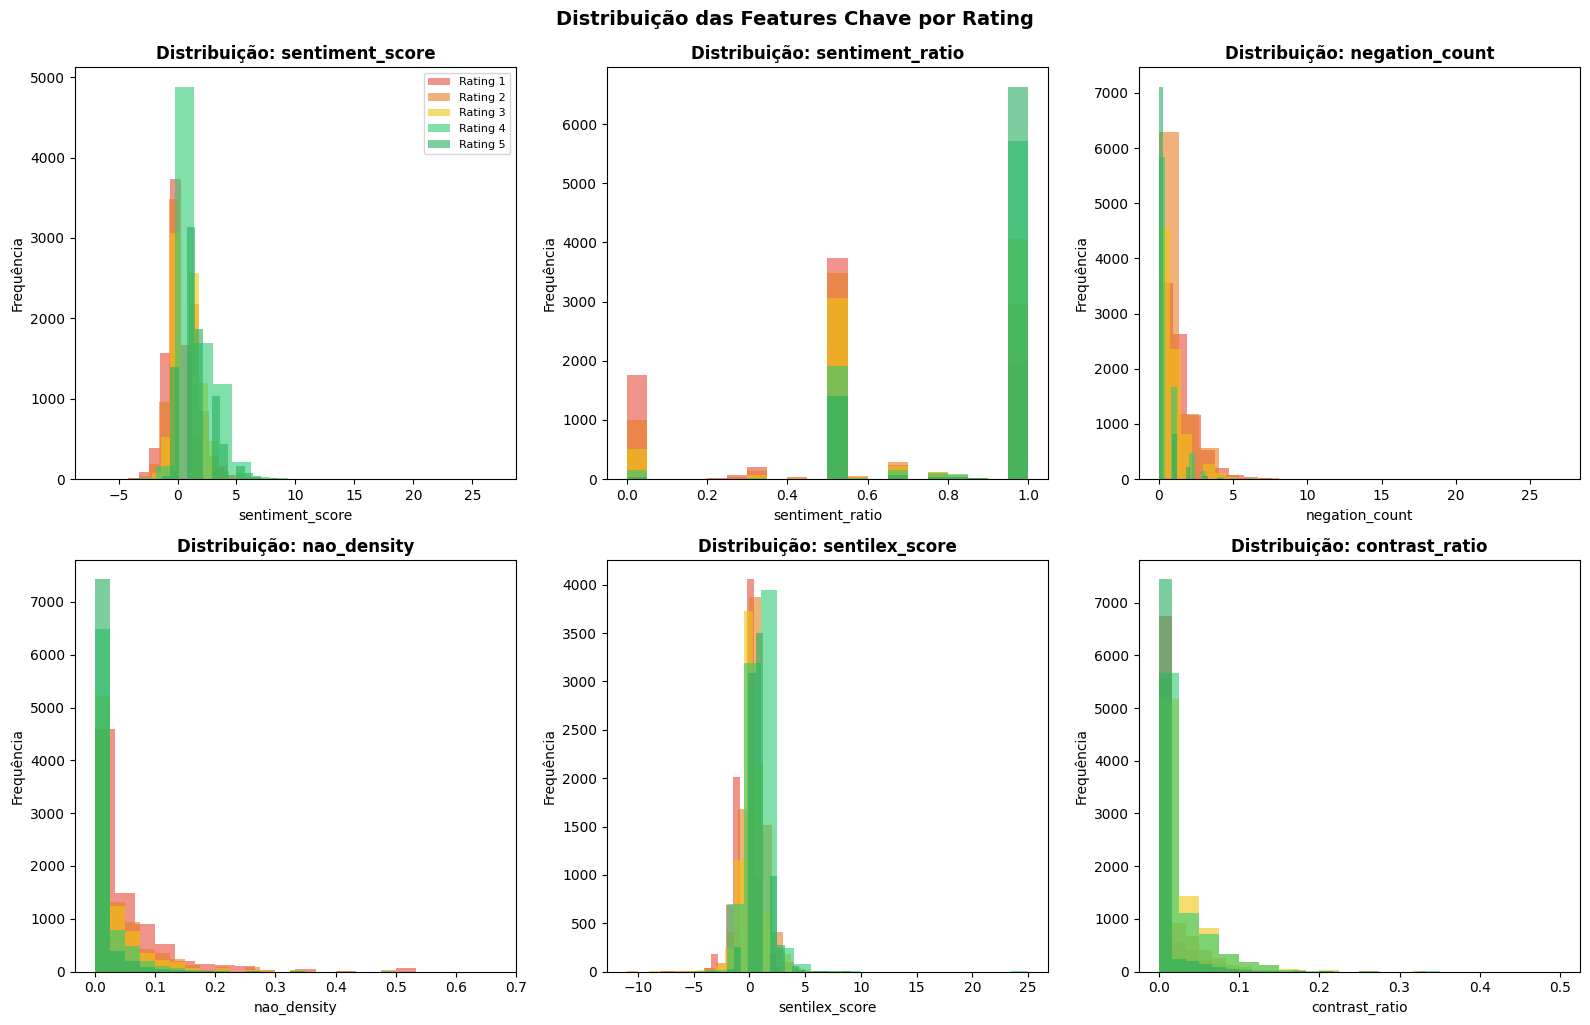

In [73]:
# ─── Distribuição de features por rating ───
key_features = [
    'sentiment_score',
    'sentiment_ratio',
    'negation_count',
    'nao_density',
    'sentilex_score',
    'contrast_ratio',
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']

for idx, feat in enumerate(key_features):
    for r, c in zip([1,2,3,4,5], colors):
        vals = df_features[df_features['rating'] == r][feat]
        axes[idx].hist(vals, bins=20, alpha=0.6, color=c, label=f'Rating {r}')
    axes[idx].set_title(f'Distribuição: {feat}', fontweight='bold')
    axes[idx].set_xlabel(feat)
    axes[idx].set_ylabel('Frequência')
    if idx == 0:
        axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.suptitle('Distribuição das Features Chave por Rating', y=1.02, fontsize=14, fontweight='bold')
plt.show()


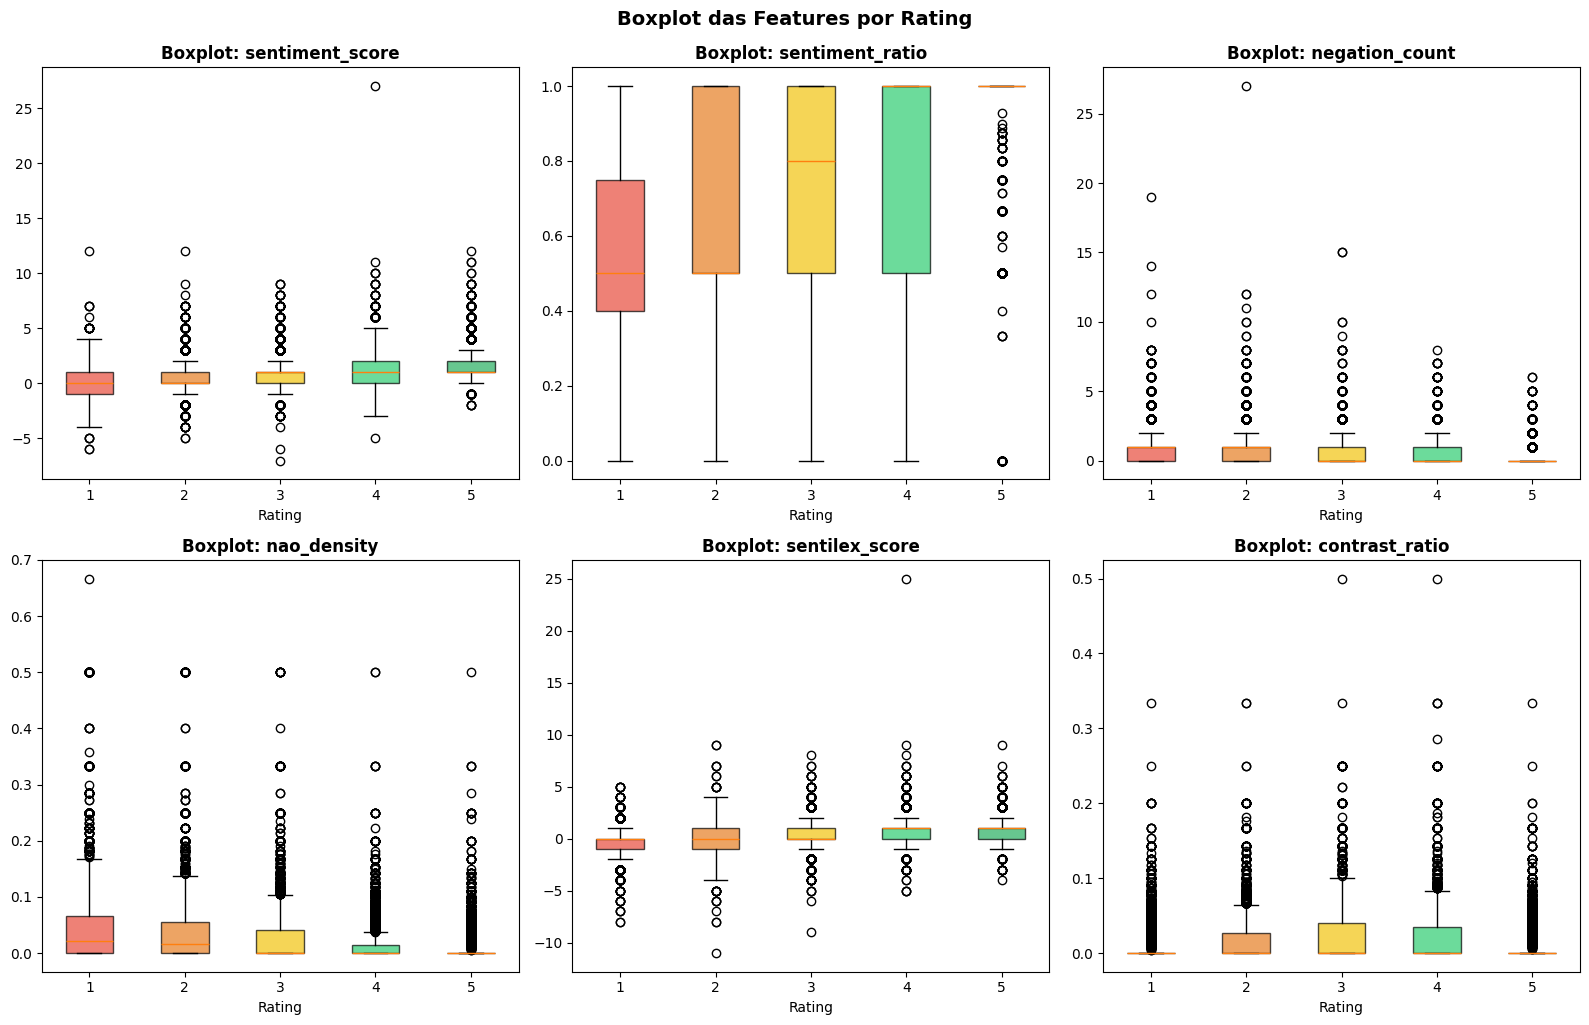

In [74]:
# ─── Média das features por rating (boxplots) ───
colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, feat in enumerate(key_features):
    data_by_rating = [df_features[df_features['rating'] == r][feat].values for r in [1,2,3,4,5]]
    bp = axes[idx].boxplot(data_by_rating, labels=[1,2,3,4,5], patch_artist=True)
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    axes[idx].set_title(f'Boxplot: {feat}', fontweight='bold')
    axes[idx].set_xlabel('Rating')

plt.tight_layout()
plt.suptitle('Boxplot das Features por Rating', y=1.02, fontsize=14, fontweight='bold')
plt.show()


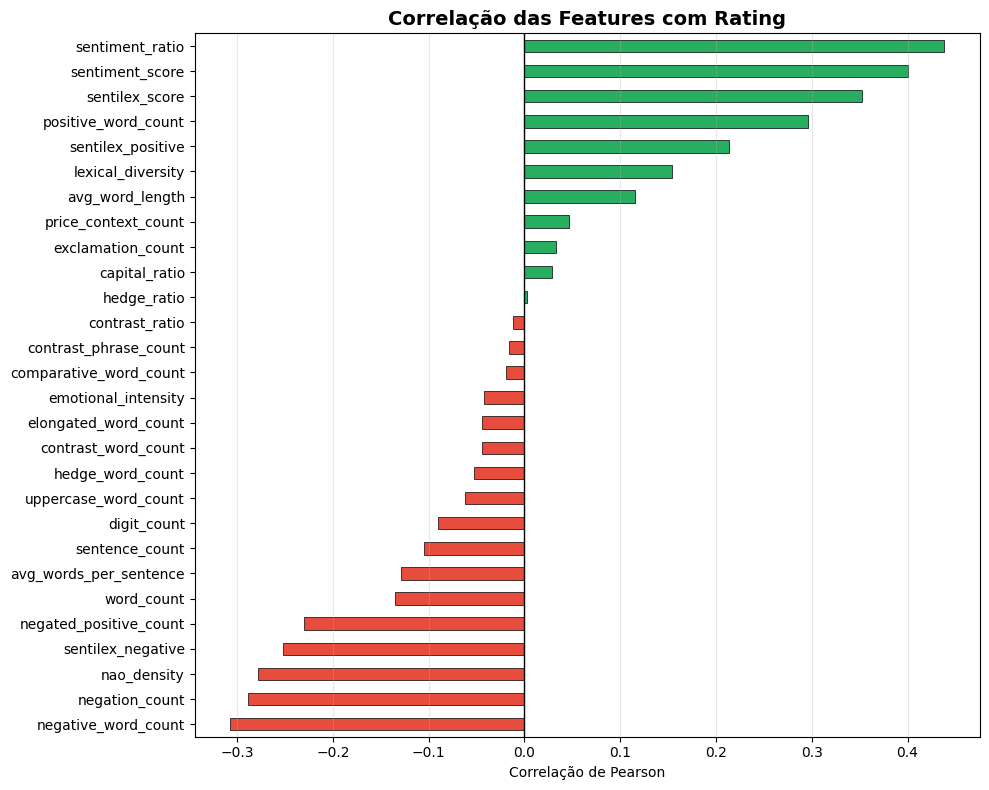


Top 10 features com maior correlação (abs) com rating:
sentiment_ratio           0.438426
sentiment_score           0.400104
sentilex_score            0.352301
negative_word_count       0.306994
positive_word_count       0.295628
negation_count            0.288585
nao_density               0.278094
sentilex_negative         0.252216
negated_positive_count    0.230435
sentilex_positive         0.213741
Name: rating, dtype: float64


In [75]:
# ─── Heatmap de correlação (features vs rating) ───
corr_with_rating = df_features.corr()['rating'].drop('rating').sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors_bar = ['#e74c3c' if v < 0 else '#27ae60' for v in corr_with_rating]
corr_with_rating.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='black', linewidth=0.5)
ax.set_title('Correlação das Features com Rating', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlação de Pearson')
ax.axvline(x=0, color='black', linewidth=1)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nTop 10 features com maior correlação (abs) com rating:')
print(corr_with_rating.abs().sort_values(ascending=False).head(10))

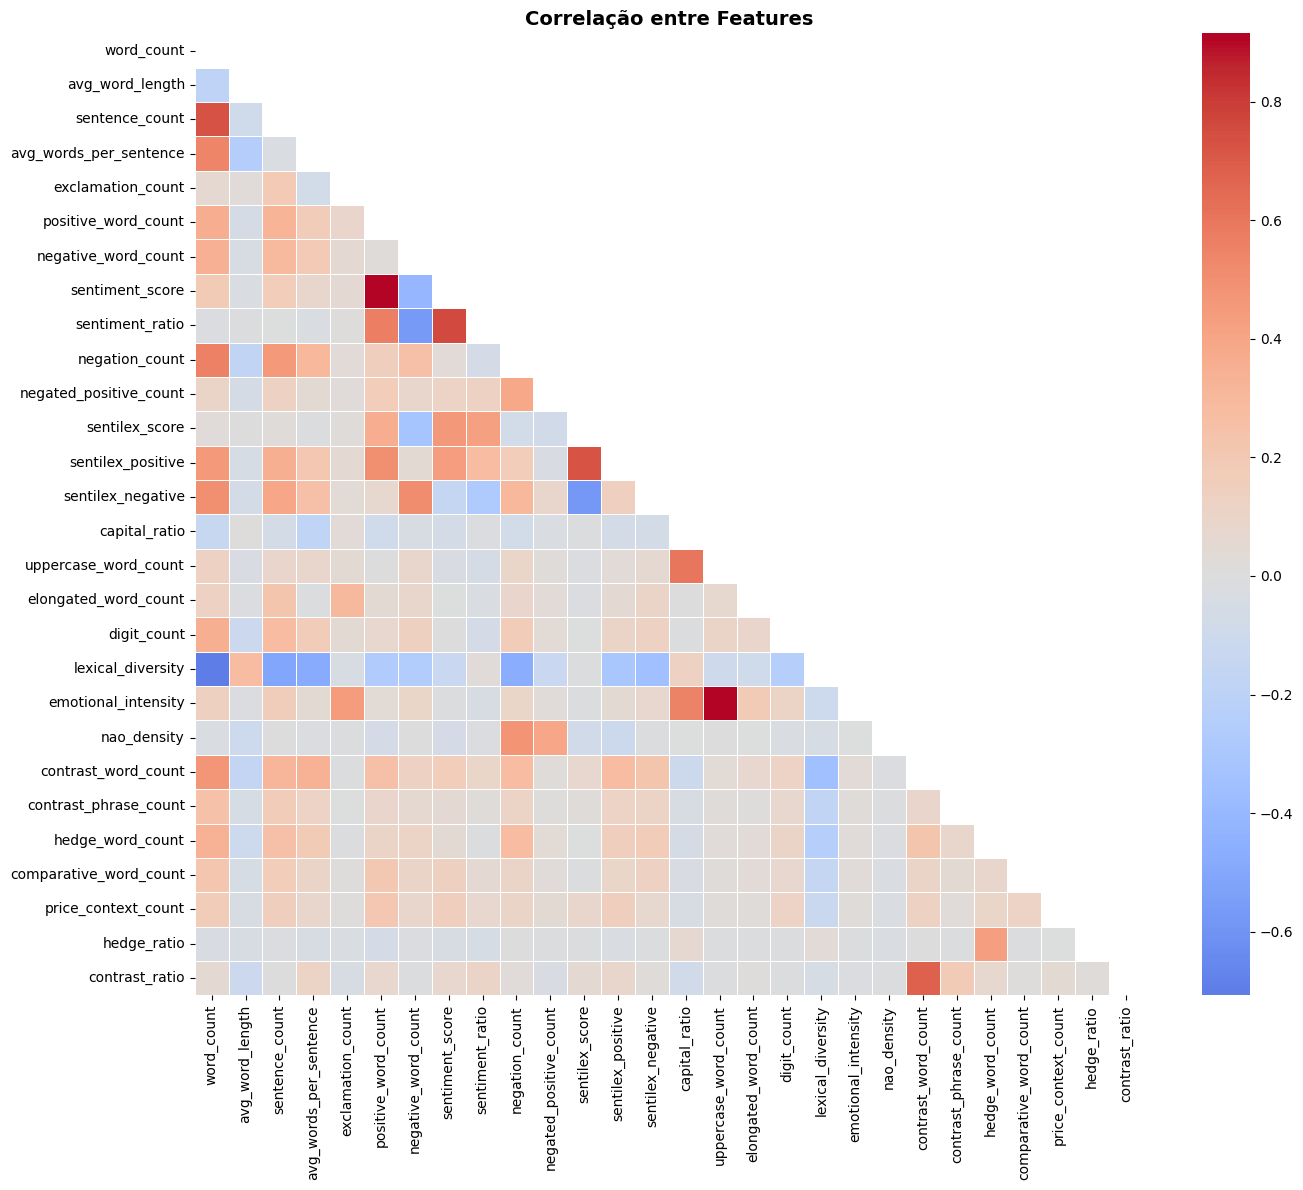

In [76]:
# ─── Heatmap de correlação entre features ───
plt.figure(figsize=(14, 12))
corr_matrix = df_features.drop('rating', axis=1).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            annot=False, fmt='.1f', linewidths=0.5)
plt.title('Correlação entre Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Describe dos Dados

In [77]:
desc = df_features.drop('rating', axis=1).describe().T
desc['cv'] = (desc['std'] / desc['mean'].abs()).round(3)  # Coef. de variação
desc = desc.round(4)

print('=== Estatísticas Descritivas das Features ===')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
print(desc[['mean','std','min','25%','50%','75%','max','cv']])

=== Estatísticas Descritivas das Features ===
                           mean      std   min     25%      50%      75%       max     cv
word_count              21.3445  22.8930   0.0  7.0000  15.0000  28.0000  869.0000  1.073
avg_word_length          4.7754   0.9985   0.0  4.2083   4.6071   5.1111   33.5000  0.209
sentence_count           1.8274   1.3951   1.0  1.0000   1.0000   2.0000   40.0000  0.763
avg_words_per_sentence  11.8461   9.5496   0.0  5.8000  10.0000  15.0000  231.0000  0.806
exclamation_count        0.2313   0.7698   0.0  0.0000   0.0000   0.0000   26.0000  3.328
positive_word_count      1.1652   1.2867   0.0  0.0000   1.0000   2.0000   27.0000  1.104
negative_word_count      0.2672   0.6005   0.0  0.0000   0.0000   0.0000   13.0000  2.247
sentiment_score          0.8981   1.4115  -7.0  0.0000   1.0000   2.0000   27.0000  1.572
sentiment_ratio          0.7252   0.3216   0.0  0.5000   1.0000   1.0000    1.0000  0.443
negation_count           0.6409   1.0398   0.0  0.0000

In [78]:
# ─── Média por rating ───
print('=== Média das features por Rating ===')
print(df_features.groupby('rating')[FEATURE_NAMES].mean().round(3).T)

=== Média das features por Rating ===
rating                       1       2       3       4       5
word_count              22.348  25.677  24.124  20.767  13.846
avg_word_length          4.762   4.658   4.596   4.727   5.133
sentence_count           1.958   2.011   1.845   1.754   1.570
avg_words_per_sentence  12.128  13.317  13.438  11.825   8.539
exclamation_count        0.305   0.159   0.129   0.177   0.386
positive_word_count      0.640   0.898   1.092   1.520   1.673
negative_word_count      0.552   0.394   0.233   0.120   0.038
sentiment_score          0.088   0.504   0.859   1.400   1.635
sentiment_ratio          0.517   0.629   0.726   0.849   0.905
negation_count           0.991   0.925   0.691   0.412   0.187
negated_positive_count   0.187   0.146   0.066   0.024   0.005
sentilex_score          -0.322  -0.020   0.279   0.628   0.765
sentilex_positive        0.351   0.571   0.718   0.901   0.891
sentilex_negative        0.673   0.591   0.438   0.273   0.126
capital_ratio    

## 9. Normalização das Features

In [79]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

print(f'X_train normalizado: shape={X_train_scaled.shape}')
print(f'X_test  normalizado: shape={X_test_scaled.shape}')
print(f'Média pós-normalização (deve ser ~0): {X_train_scaled.mean(axis=0)[:5].round(6)}')
print(f'Std pós-normalização  (deve ser ~1): {X_train_scaled.std(axis=0)[:5].round(6)}')

X_train normalizado: shape=(41005, 28)
X_test  normalizado: shape=(10252, 28)
Média pós-normalização (deve ser ~0): [-0. -0.  0. -0.  0.]
Std pós-normalização  (deve ser ~1): [1. 1. 1. 1. 1.]


## 10. Treinamento — SVM com Validação Cruzada

In [80]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma=0.1,
    class_weight='balanced',
    random_state=SEED
)

print('Rodando validação cruzada (5-fold) — SVM RBF...')
svm_scores = cross_val_score(svm_model, X_train_scaled, y_train, cv=kf, scoring='accuracy', n_jobs=-1)

print(f'\n📊 SVM — Acurácia por fold: {[round(s,4) for s in svm_scores]}')
print(f'📊 SVM — Média: {svm_scores.mean():.4f}  |  Std: {svm_scores.std():.4f}')

Rodando validação cruzada (5-fold) — SVM RBF...

📊 SVM — Acurácia por fold: [np.float64(0.3932), np.float64(0.3947), np.float64(0.3947), np.float64(0.3946), np.float64(0.3964)]
📊 SVM — Média: 0.3947  |  Std: 0.0010


In [81]:
# ─── Comparação com outros modelos clássicos ───
models = {
    'SVM (RBF, C=10)': SVC(kernel='rbf', C=10, gamma=0.1, class_weight='balanced', random_state=SEED),
    'SVM (Linear)': SVC(kernel='linear', C=1, class_weight='balanced', random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=15, random_state=SEED, n_jobs=-1),
    'Logistic Regression': LogisticRegression(C=1, max_iter=500, random_state=SEED, n_jobs=-1),
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='accuracy', n_jobs=-1)
    results[name] = scores
    print(f'{name:35s} | Folds: {[round(s,4) for s in scores]} | Média: {scores.mean():.4f}')

print('\n🏆 Melhor modelo:', max(results, key=lambda k: results[k].mean()))

SVM (RBF, C=10)                     | Folds: [np.float64(0.3932), np.float64(0.3947), np.float64(0.3947), np.float64(0.3946), np.float64(0.3964)] | Média: 0.3947
SVM (Linear)                        | Folds: [np.float64(0.4067), np.float64(0.405), np.float64(0.4076), np.float64(0.4092), np.float64(0.407)] | Média: 0.4071
Random Forest                       | Folds: [np.float64(0.4165), np.float64(0.4112), np.float64(0.4212), np.float64(0.4189), np.float64(0.4185)] | Média: 0.4172
Logistic Regression                 | Folds: [np.float64(0.4213), np.float64(0.4117), np.float64(0.4245), np.float64(0.4139), np.float64(0.4173)] | Média: 0.4177

🏆 Melhor modelo: Logistic Regression


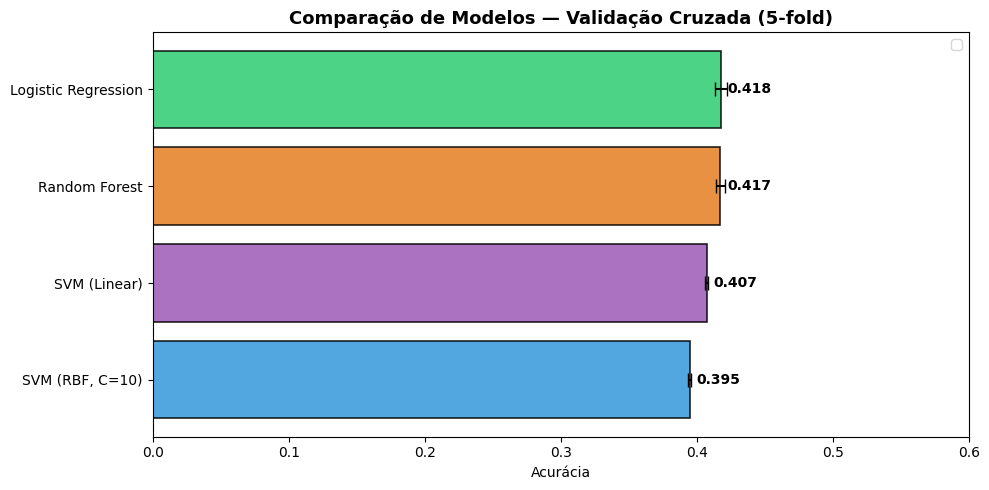

In [82]:
# ─── Visualização dos resultados ───
fig, ax = plt.subplots(figsize=(10, 5))

model_names = list(results.keys())
means = [results[m].mean() for m in model_names]
stds  = [results[m].std()  for m in model_names]

bars = ax.barh(model_names, means, xerr=stds, color=['#3498db','#9b59b6','#e67e22','#2ecc71'],
               edgecolor='black', linewidth=1.2, capsize=5, alpha=0.85)
ax.set_xlim(0, 0.6)
ax.set_title('Comparação de Modelos — Validação Cruzada (5-fold)', fontsize=13, fontweight='bold')
ax.set_xlabel('Acurácia')
for bar, val in zip(bars, means):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 11. Média dos Folds

In [83]:
print('=' * 55)
print('RESUMO — MÉDIA DOS FOLDS (5-fold CV, seed=42)')
print('=' * 55)
for name, scores in results.items():
    print(f'{name:35s}: {scores.mean():.4f} ± {scores.std():.4f}')
print('=' * 55)

best_model_name = max(results, key=lambda k: results[k].mean())
print(f'\n🥇 Melhor modelo: {best_model_name} ({results[best_model_name].mean():.4f})')

RESUMO — MÉDIA DOS FOLDS (5-fold CV, seed=42)
SVM (RBF, C=10)                    : 0.3947 ± 0.0010
SVM (Linear)                       : 0.4071 ± 0.0014
Random Forest                      : 0.4172 ± 0.0034
Logistic Regression                : 0.4177 ± 0.0047

🥇 Melhor modelo: Logistic Regression (0.4177)


## 11.1 Avaliação: QWK e matriz de confusão (OOF)

Predições **out-of-fold** com o mesmo `KFold` — cada amostra é predita por um modelo treinado **sem** ela no treino. Isso evita viés otimista (diferente de avaliar no treino após `fit` no conjunto inteiro).

- **QWK** (`cohen_kappa_score`, `weights='quadratic'`): penaliza mais erros grandes na escala 1–5.
- **Matriz de confusão**: classes reais (linhas) × preditas (colunas).

Modelo (OOF): Logistic Regression
Accuracy (OOF): 0.4177
QWK (quadratic): 0.5974

              precision    recall  f1-score   support

           1     0.4394    0.6506    0.5245      8205
           2     0.3320    0.1706    0.2254      8178
           3     0.3255    0.2763    0.2989      8194
           4     0.3520    0.2482    0.2911      8198
           5     0.5115    0.7407    0.6052      8230

    accuracy                         0.4177     41005
   macro avg     0.3921    0.4173    0.3890     41005
weighted avg     0.3922    0.4177    0.3893     41005



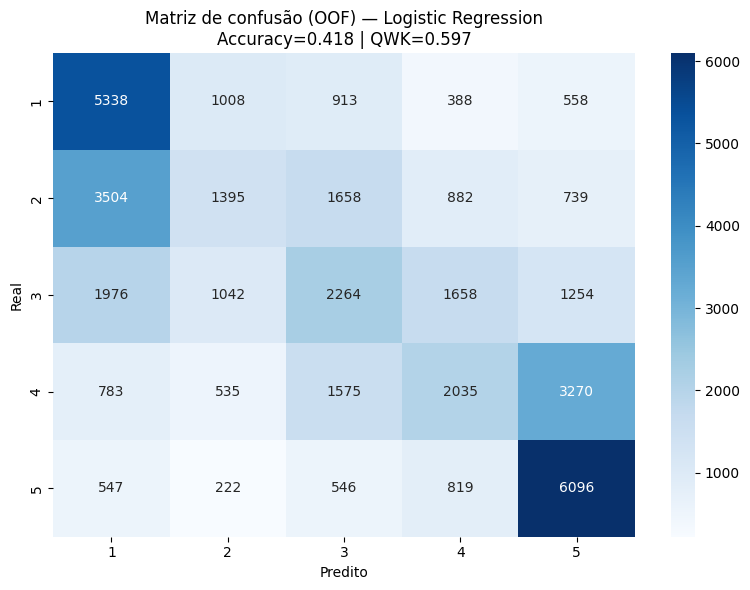

In [84]:
RATING_LABELS = [1, 2, 3, 4, 5]

# Clone do melhor estimador (cross_val_predict também clona internamente; assim não acumulamos estado em `models[...]`)
est_oof = clone(models[best_model_name])
y_oof = cross_val_predict(est_oof, X_train_scaled, y_train, cv=kf, n_jobs=-1)

acc_oof = accuracy_score(y_train, y_oof)
qwk_oof = cohen_kappa_score(y_train, y_oof, labels=RATING_LABELS, weights='quadratic')
cm_oof = confusion_matrix(y_train, y_oof, labels=RATING_LABELS)

print(f'Modelo (OOF): {best_model_name}')
print(f'Accuracy (OOF): {acc_oof:.4f}')
print(f'QWK (quadratic): {qwk_oof:.4f}')
print()
print(classification_report(y_train, y_oof, labels=RATING_LABELS, digits=4))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm_oof,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=RATING_LABELS,
    yticklabels=RATING_LABELS,
    ax=ax,
)
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
ax.set_title(f'Matriz de confusão (OOF) — {best_model_name}\nAccuracy={acc_oof:.3f} | QWK={qwk_oof:.3f}')
plt.tight_layout()
plt.show()

## 12. Treinamento no Conjunto Completo

In [85]:
# Treinar o melhor modelo no dataset completo
best_model = models[best_model_name]
print(f'Treinando {best_model_name} no dataset completo...')
best_model.fit(X_train_scaled, y_train)
train_acc = best_model.score(X_train_scaled, y_train)
print(f'✅ Treinamento concluído! Acurácia no treino: {train_acc:.4f}')

Treinando Logistic Regression no dataset completo...
✅ Treinamento concluído! Acurácia no treino: 0.4201


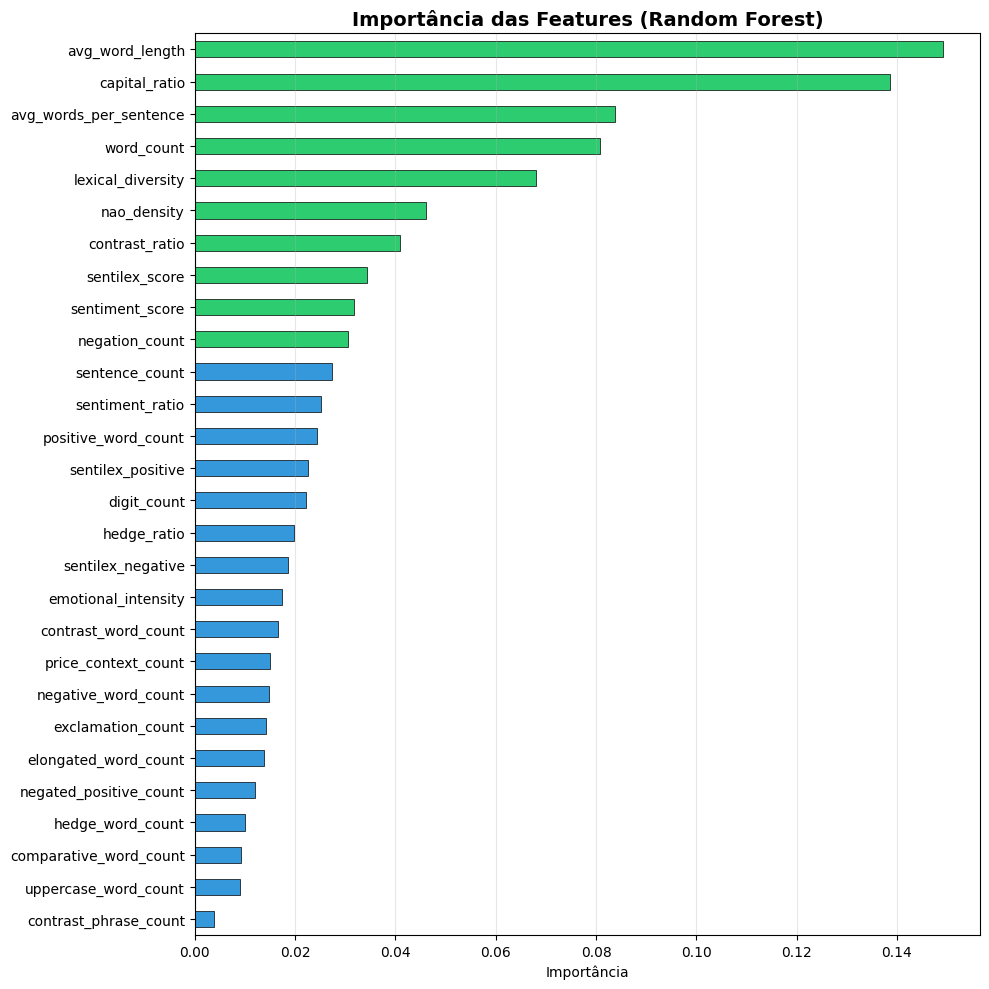


🏆 Top 10 features mais importantes:
avg_word_length           0.149095
capital_ratio             0.138684
avg_words_per_sentence    0.083880
word_count                0.080780
lexical_diversity         0.068125
nao_density               0.046071
contrast_ratio            0.040934
sentilex_score            0.034372
sentiment_score           0.031748
negation_count            0.030634
dtype: float64


In [86]:
# ─── Importância de features (via Random Forest) ───
rf_for_importance = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
rf_for_importance.fit(X_train_scaled, y_train)

importances = pd.Series(rf_for_importance.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
colors_imp = ['#2ecc71' if i >= len(importances) - 10 else '#3498db' for i in range(len(importances))]
importances.plot(kind='barh', ax=ax, color=colors_imp, edgecolor='black', linewidth=0.5)
ax.set_title('Importância das Features (Random Forest)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importância')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('\n🏆 Top 10 features mais importantes:')
print(importances.sort_values(ascending=False).head(10))

## 13. Predições e Submissão

In [87]:
predictions = best_model.predict(X_test_scaled)

submission = pd.DataFrame({
    'id': test['id'],
    'rating': predictions
})

submission.to_csv('submission.csv', index=False)

print(f'✅ Arquivo submission.csv gerado!')
print(f'   Total de predições: {len(submission)}')
print(f'\nDistribuição das predições:')
print(submission['rating'].value_counts().sort_index())
print(f'\nPrimeiras 10 predições:')
print(submission.head(10))

✅ Arquivo submission.csv gerado!
   Total de predições: 10252

Distribuição das predições:
rating
1    2961
2     994
3    1784
4    1391
5    3122
Name: count, dtype: int64

Primeiras 10 predições:
      id  rating
0  40261       4
1  46176       1
2  47942       4
3  37329       2
4  13503       5
5  41006       5
6  42233       5
7  21180       3
8  20621       2
9  28630       5


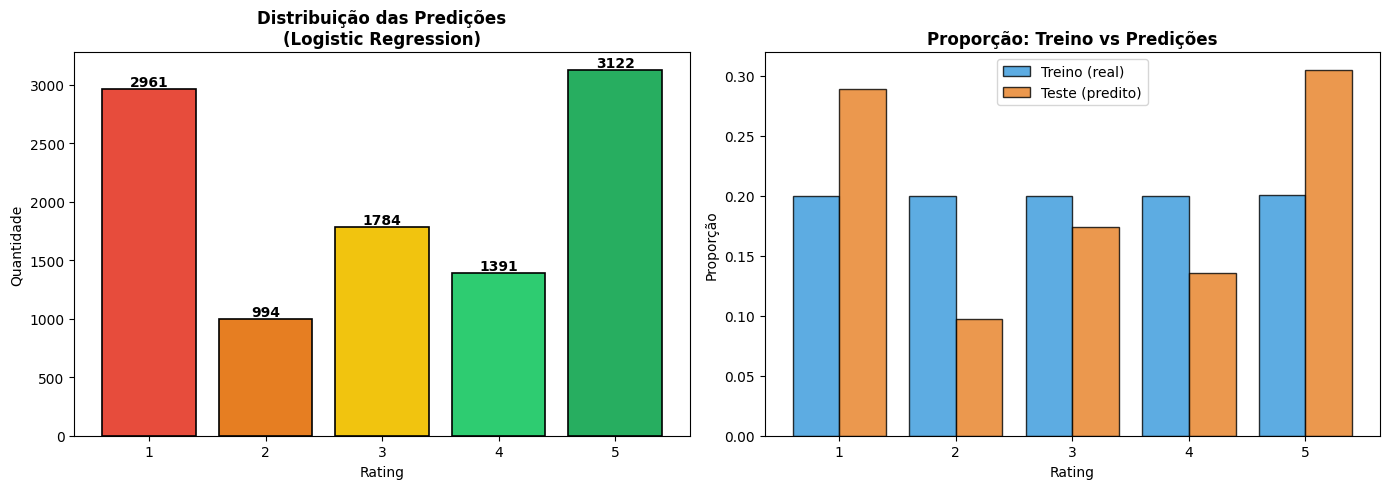

In [88]:
# ─── Visualização das predições ───
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predições
pred_counts = submission['rating'].value_counts().sort_index()
axes[0].bar(pred_counts.index, pred_counts.values, color=colors, edgecolor='black', linewidth=1.2)
for i, (idx, val) in enumerate(pred_counts.items()):
    axes[0].annotate(f'{val}', xy=(idx, val), ha='center', va='bottom', fontweight='bold')
axes[0].set_title(f'Distribuição das Predições\n({best_model_name})', fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Quantidade')

# Comparação treino vs predição
train_counts = train['rating'].value_counts().sort_index()
x = np.arange(1, 6)
axes[1].bar(x - 0.2, train_counts.values / train_counts.sum(), 0.4,
            label='Treino (real)', color='#3498db', alpha=0.8, edgecolor='black')
axes[1].bar(x + 0.2, pred_counts.values / pred_counts.sum(), 0.4,
            label='Teste (predito)', color='#e67e22', alpha=0.8, edgecolor='black')
axes[1].set_title('Proporção: Treino vs Predições', fontweight='bold')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Proporção')
axes[1].legend()
axes[1].set_xticks(x)

plt.tight_layout()
plt.show()